In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
np.random.seed(42)
n_days= 365

In [4]:
data = {
    'day_of_week': np.random.randint(0, 7, n_days),
    'is_weekend': np.random.randint(0, 2, n_days),
    'temp_celsius': np.random.uniform(5, 30, n_days),
    'rain_snow': np.random.randint(0, 2, n_days),
    'local_event': np.random.choice([0, 1], n_days, p=[0.8, 0.2]),
    'prev_3d_avg': np.random.uniform(80, 150, n_days)
}
df = pd.DataFrame(data)

In [5]:
y= (df['is_weekend']* 40)+ (df['local_event'] * 50)+ (df['temp_celsius']* 0.5)- (df['rain_snow']* 15)+ 100+ np.random.normal(0, 5, n_days)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = models.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

In [9]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [10]:
print("Trenowanie sieci...")
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=10, validation_split=0.2, verbose=0)

Trenowanie sieci...


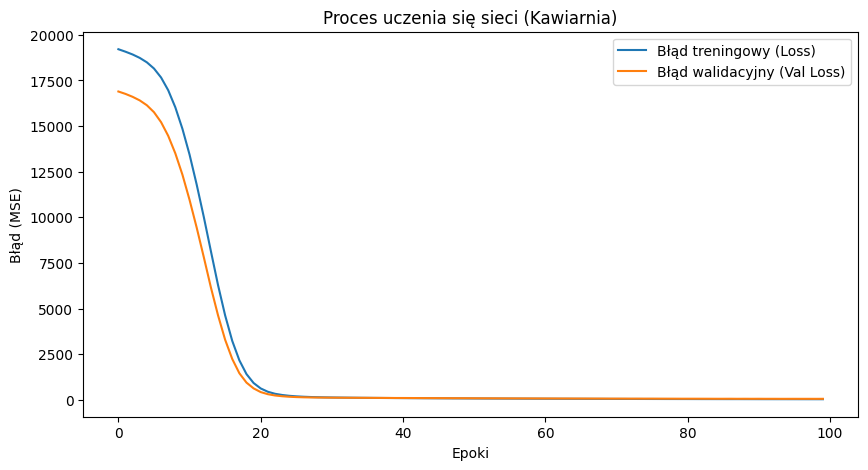

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Błąd treningowy (Loss)')
plt.plot(history.history['val_loss'], label='Błąd walidacyjny (Val Loss)')
plt.title('Proces uczenia się sieci (Kawiarnia)')
plt.xlabel('Epoki')
plt.ylabel('Błąd (MSE)')
plt.legend()
plt.show()

In [12]:
sample_pred = model.predict(X_test_scaled[:5])
print("\n---Przykładowe prognozy---")
for i in range(5):
    print(f"Przewidywano: {int(sample_pred[i][0])} osób, Faktycznie było: {int(y_test.iloc[i])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

---Przykładowe prognozy---
Przewidywano: 140 osób, Faktycznie było: 161
Przewidywano: 144 osób, Faktycznie było: 155
Przewidywano: 105 osób, Faktycznie było: 109
Przewidywano: 135 osób, Faktycznie było: 142
Przewidywano: 146 osób, Faktycznie było: 138


In [13]:
dane_przyszly_tydzien = pd.DataFrame({
    'day_of_week': [0, 1, 2, 3, 4],
    'is_weekend': [0, 0, 0, 0, 0],
    'temp_celsius': [16, 19, 23, 15, 17],
    'rain_snow': [0, 0, 0, 1, 0],
    'local_event': [0, 0, 1, 0, 0],
    'prev_3d_avg': [115, 118, 120, 125, 122]
})

In [14]:
dane_skalowane = scaler.transform(dane_przyszly_tydzien)

In [15]:
wyniki_sieci = model.predict(dane_skalowane).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [16]:
dni_tygodnia = ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 'Piątek']
raport_finalny = pd.DataFrame({
    'Dzień': dni_tygodnia,
    'Przewidywana liczba gości': wyniki_sieci.astype(int)
})

In [17]:
def ustal_obsade(liczba):
    if liczba > 135:
        return "Wzmocniona obsada (3 os.)+ większy wypiek"
    else:
        return "Standard (2 os.)"
raport_finalny['Zalecenie'] = raport_finalny['Przewidywana liczba gości'].apply(ustal_obsade)

In [18]:
print("\n---Harmonogram operacyjny Kawiarni---")
print(raport_finalny.to_string(index=False))


---Harmonogram operacyjny Kawiarni---
       Dzień  Przewidywana liczba gości                                 Zalecenie
Poniedziałek                        106                          Standard (2 os.)
      Wtorek                        104                          Standard (2 os.)
       Środa                        159 Wzmocniona obsada (3 os.)+ większy wypiek
    Czwartek                         85                          Standard (2 os.)
      Piątek                        100                          Standard (2 os.)
